# MNIST
## 05. K-means clustering

In [1]:
import numpy as np
from infdsa_mnist import mnist_load_normalized, mnist_output, k_means, k_means_output

np.random.seed(70000)  # Using 70000 as the seed for reproducibility, based on the fact the MNIST dataset has 70,000 total images.

Up until this point, we have been working with the MNIST dataset in a supervised learning context, where we have access to both the input data (the images of handwritten digits) and the corresponding labels (the digit classes). However, in some cases, we may not have access to the labels, or we may want to explore the structure of the data without relying on the labels. In such cases, we can use unsupervised learning techniques like, k-means clustering, to group similar data points together based on their features. This can help us identify patterns and structures in the data that occur naturally, without the need for labeled examples. For example, we can figure out there are lots of 1's that look incredibly similar to 7's, and have all of those 1's grouped together in a cluster, close to a cluster of 7's. This can be useful for understanding the underlying structure of the data, and to help us create prototypes of the classes. This can be especially useful as a preprocessing step for supervised learning, as it can help us create better features for our models. As this chapter is exploratory in nature, we will not ask a single main question, but rather divide the chapter into several sections to naturally explore the concept of k-means clustering and its application to the MNIST dataset.
1. What is a prototype in the context of k-means clustering, and how does this save memory?
2. Make several prototypes of each digit class in the MNIST dataset using k-means clustering.
3. Predict the digit class of unseen digits using the prototypes created in section 2.
4. Further experimentation

## What is a prototype in the context of k-means clustering, and how does this save memory?
In the context of k-means clustering, a prototype is a data point at the center of a cluster. This data point is often referred to as the centroid of the cluster and it represents the average of all the data points in that cluster. The prototype can be used to represent the entire cluster, which can save memory, as well as computational resources, when working with large datasets. In fact, the larger the dataset, the more savings in memory and computational resources we can achieve by using prototypes. Instead of storing and processing all individual datapoints, we can store and process only the prototypes, which can significantly reduce the amount of memory and computational resources required to work with the data. This is especially useful when working with high-dimensional data, such as images, where each data point can have a large number of features (e.g., pixels). By using prototypes, we can effectively summarize the data and make it more manageable for analysis and modeling.

In [2]:
(train_data, test_data) = mnist_load_normalized.load_mnist_normalized()
x_train, y_train = train_data
x_test, y_test = test_data

## Making prototypes of each digit class in the MNIST dataset using k-means clustering

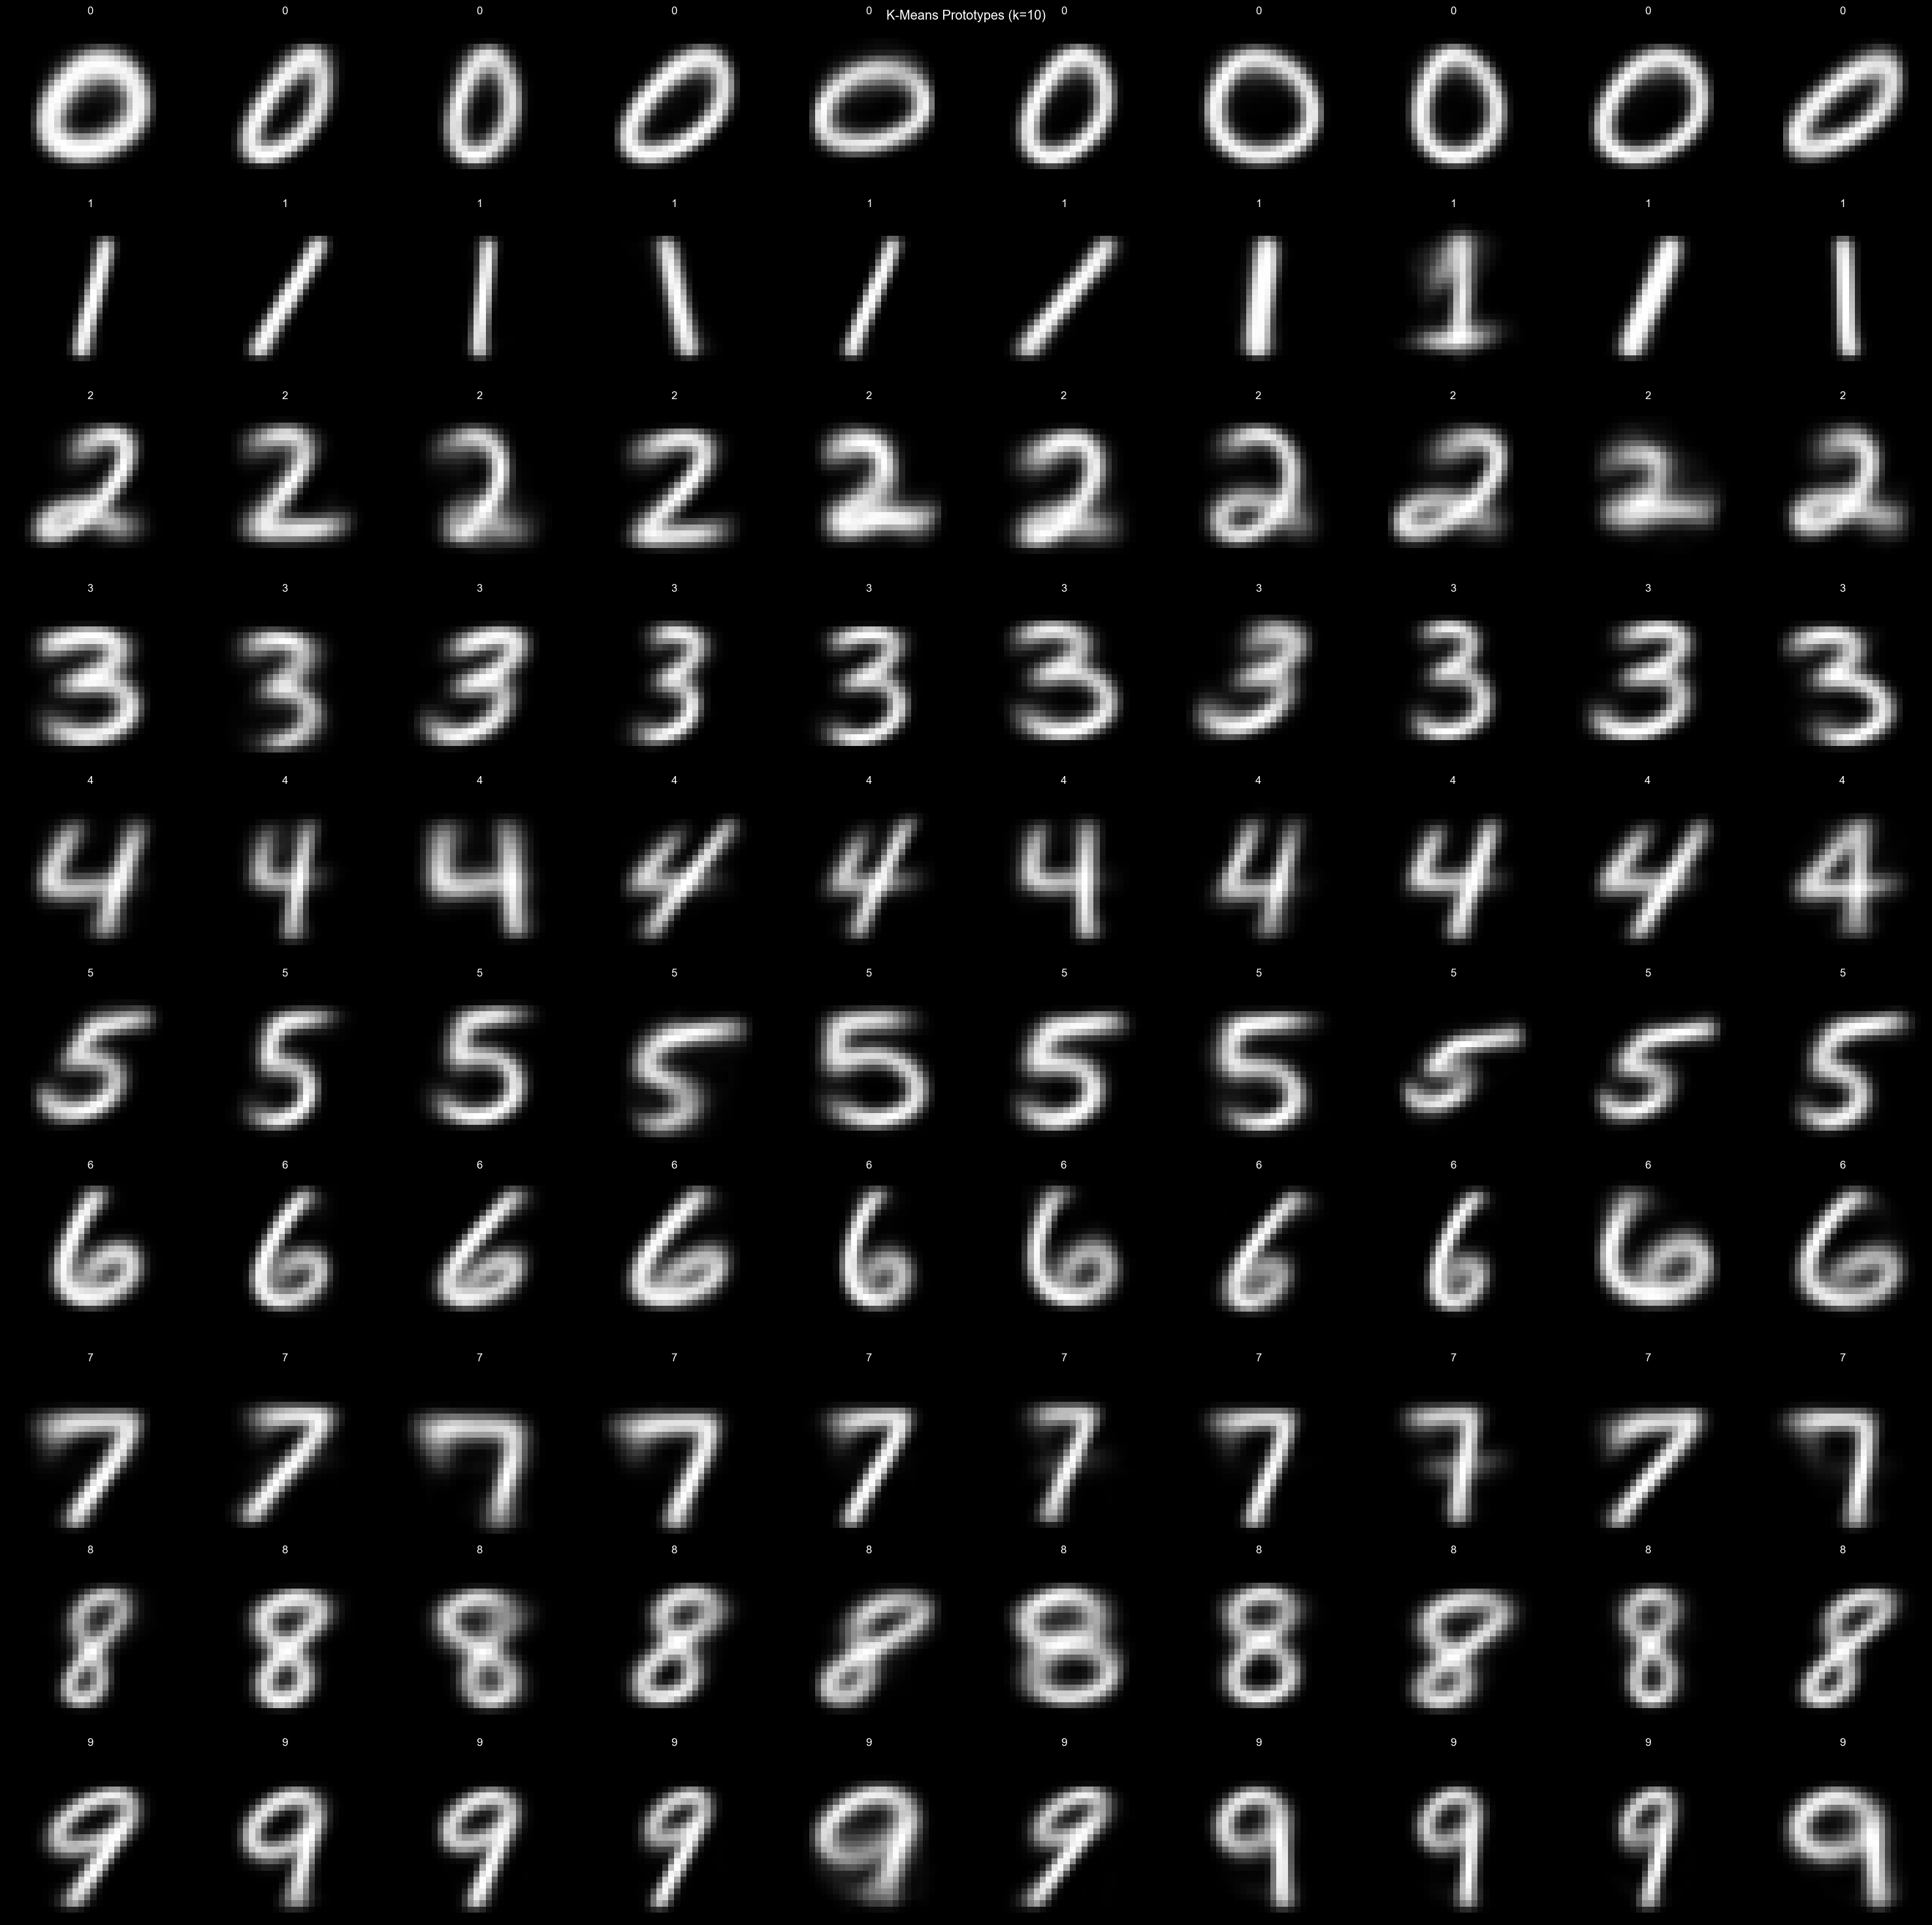

In [3]:
prototypes_per_digit = 10
use_sklearn = False  # False is slower, but custom
prototypes, prototype_labels = k_means.make_prototype(x_train, y_train, prototypes_per_digit, use_sklearn)

k_means_output.plot_prototypes(prototypes, prototype_labels, prototypes_per_digit)

`make_prototype` takes the training data and labels, the number of prototypes we want per digit class, as well as a boolean flag to indicate whether we want to use the standard sklearn implementation of k-means or a custom implementation.
The custom implementation uses NumPy heavily. It is a little slower than the standard sklearn implementation, mostly because sklearn uses Cython to optimize the code, which allows it to run much faster than pure Python + NumPy. Despite all this, the custom implementation did improve a lot over time, going from 22 seconds all the way down to 4 seconds.
Alongside this, instead of merely going for k-means, we opted for k-means++, which simply means that we start with a random centroid, and then we iteratively select the next centroids based on the distance from the already selected centroids. This helps to ensure that the initial centroids are well spread out, which can lead to better clustering results. In our case, this means that the prototypes we create are more representative of the different digit classes in the MNIST dataset, which can lead to better performance when we use these prototypes for prediction.

We have opted for a standard of 10 prototypes per digit class, which is a good early-stage choice, as it captures a good amount of variation within each digit class whilst keeping the amount of prototypes manageable. However, for the sake of modularity, we have made it a variable that can be adjusted above.

## Predicting unseen digit classes based on the prototypes created in section 2

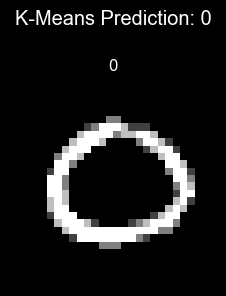

In [4]:
unseen_digit = x_test[np.random.choice(len(x_test))]

predictions = k_means.predict(unseen_digit, prototypes, prototype_labels)
k_means_output.plot_prediction(unseen_digit, predictions)

Within the context of prediction, we use "distance" to determine how close an unseen digit is to each of the prototypes. In this case, we use the Euclidean distance, which makes sense in the context of images and k-means clustering. The unseen digit is assigned to the class of the closest prototype. We do this because the closest prototype matches the unseen digit the best out of all prototypes, and is therefore the best guess the model can make based on the prototypes it has.

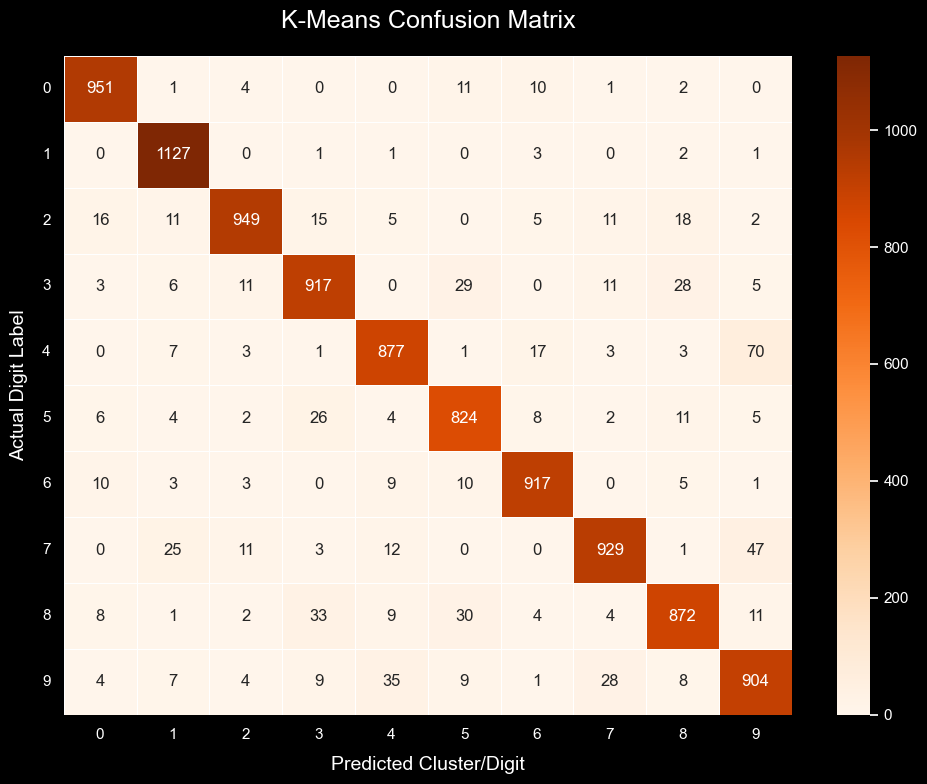

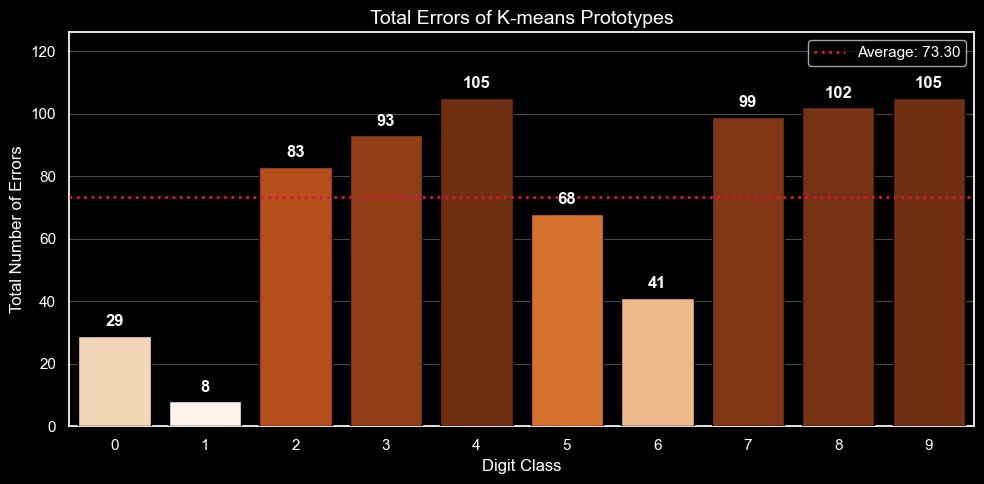

In [5]:
unseen_digits = x_test
predictions = k_means.predict_all(unseen_digits, prototypes, prototype_labels)
cm = k_means.create_confusion_matrix(y_test, predictions)

k_means_output.display_full_confusion_matrix(cm)
mnist_output.display_total_errors_barplot(cm, title="Total Errors of K-means Prototypes")

As we can see from the confusion matrix and the total errors bar plot, the performance of the k-means prototypes is actually quite good, especially considering we only use 10 prototypes per class. The model is able to correctly classify a large portion of the unseen digits, which is impressive given it is an unsupervised learning technique. However, there are still some misclassifications, which is expected given the nature of the problem and the fact we are using a relatively small number of prototypes. The performance can be further improved by increasing the number of prototypes per class.

To give a sense of the differences in performance between the custom implementation and the sklearn implementation, we can compare the total errors for each digit class. For each of the digit classes, as well as the average, the better performing model will have their number in bold.

| Digit Class | Total Errors (Sklearn) | Total Errors (Custom) |
|-------------|------------------------|-----------------------|
| Average     | **73.20**              | 73.30                 |
| 0           | 31                     | **29**                |
| 1           | 10                     | **8**                 |
| 2           | **78**                 | 83                    |
| 3           | **92**                 | 93                    |
| 4           | 106                    | **105**               |
| 5           | 75                     | **68**                |
| 6           | **36**                 | 41                    |
| 7           | **95**                 | 99                    |
| 8           | 102                    | 102                   |
| 9           | 107                    | **105**               |

Since the digit '8' has an equal amount of errors for both models, both the sklearn and custom implementations have an equal number of numbers in bold. However, since the sklearn implementation has a slightly better average, it is overall a better performing model. Still, we can see that the custom implementation holds its own against the sklearn implementation, and in the case of the digit '5,' it actually takes the digit below the average, which is quite impressive. This shows that the custom implementation is very competitive with the sklearn implementation, and since it is custom built, it can be further optimized and improved upon in the future. This makes it a great starting point for further experimentation.

Therefore, in the next section, we will experiment with k-means clustering using the custom implementation.

## Further experimentation

In the previous sections, we have explored the concept of k-means clustering and how it can be applied to the MNIST dataset. In this section, we will systematically test our custom k-means implementation with different numbers of prototypes per digit class, and analyze the impact on accuracy and memory usage.

Our goal is to observe the trade-off between these metrics:
- Accuracy: How well the model predicts unseen digits.
- Memory Usage: How much RAM the prototypes consume.

We will test with different values of k: 1, 3, 5, 10, 25, 50, and 100 prototypes per digit class. We will then analyze how the accuracy and memory usage change as we increase the number of prototypes.

========== K-Means Evaluation (k=1) ==========
Accuracy:      0.8203 (82.03%)
Memory Usage:  61.25 KB
Execution Time:0.34 seconds


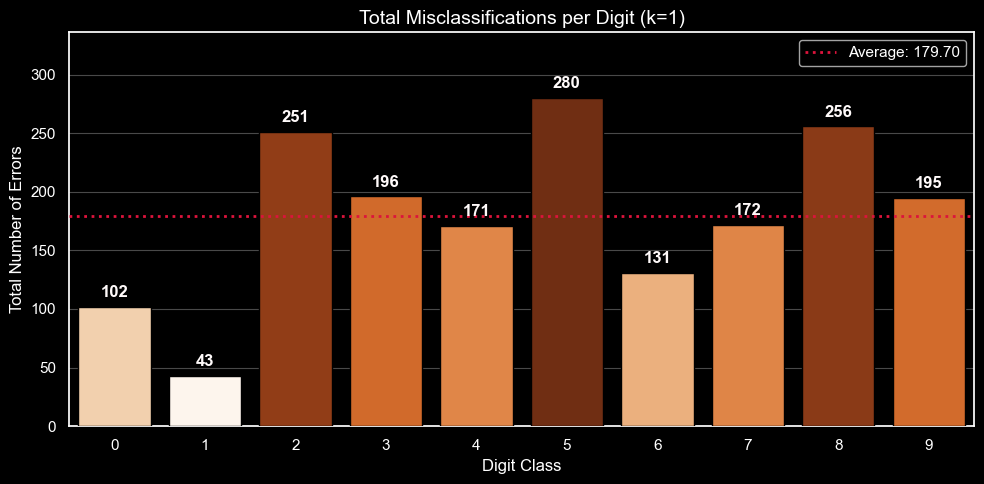

========== K-Means Evaluation (k=3) ==========
Accuracy:      0.8802 (88.02%)
Memory Usage:  183.75 KB
Execution Time:1.35 seconds


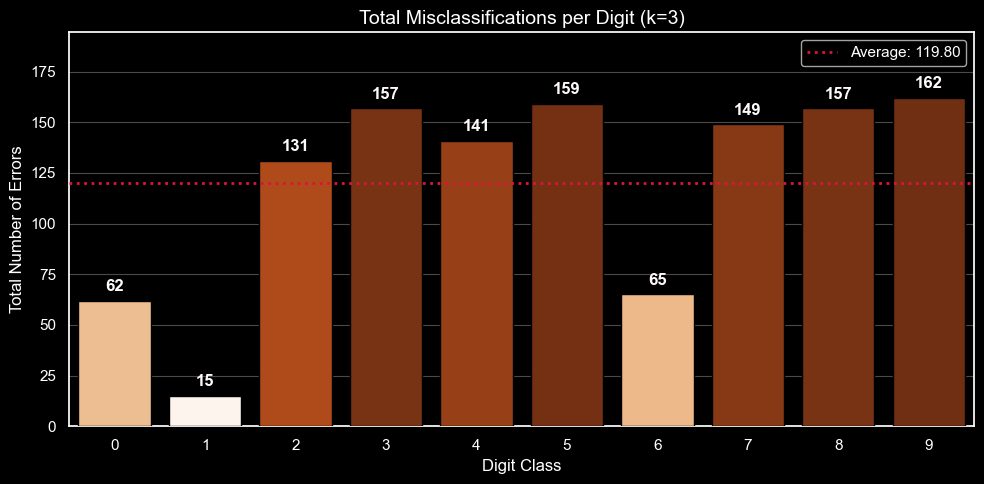

========== K-Means Evaluation (k=4) ==========
Accuracy:      0.8940 (89.40%)
Memory Usage:  245.0 KB
Execution Time:4.73 seconds


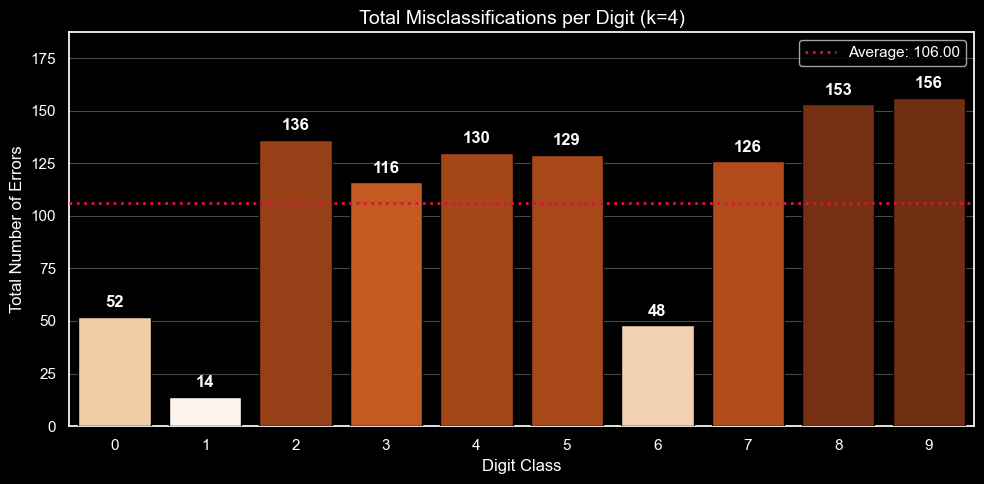

========== K-Means Evaluation (k=5) ==========
Accuracy:      0.9069 (90.69%)
Memory Usage:  306.25 KB
Execution Time:4.57 seconds


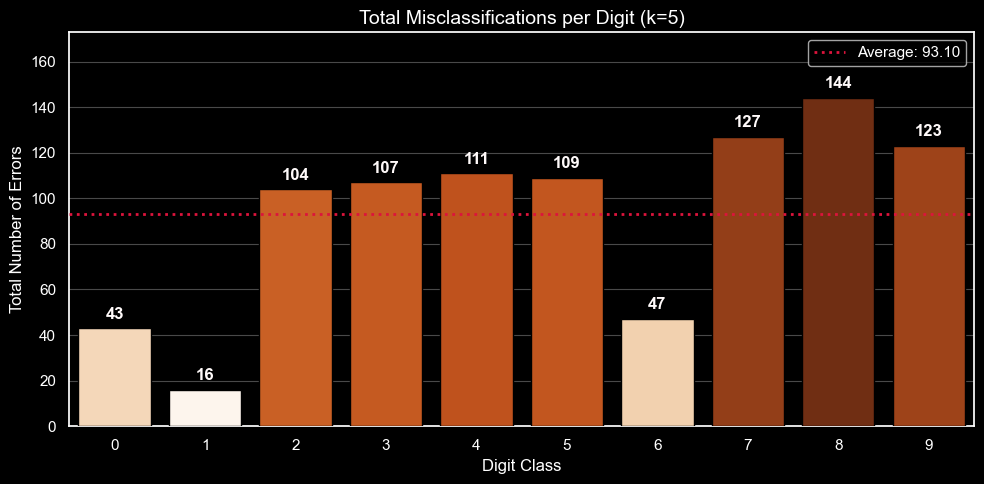

In [ ]:
prototypes_per_digit_values = [1, 3, 4, 5, 10, 20]
results = {}

for k in prototypes_per_digit_values:
    np.random.seed(70000)
    result_data = k_means.evaluate_model(train_data, test_data, k)  # dict
    k_means_output.display_evaluation_metrics(result_data)

    for key, value in result_data.items():
        if key not in results:
            results[key] = []
        results[key].append(value)


k_means_output.plot_accuracy_vs_memory(results)

Before we dive further into the results and what they mean, a keen eye might have spotted a reinitialization of the random seed at the start of the for-loop. We do this to ensure the random seed is always initialized, meaning that the results are reproducible, even outside the for-loop. This is important for this experiment, as ignoring the random seed initialization step, by blindly using the seed set at the start of this notebook, would result in different results compared to the ones we get here. For example, if we were to run the code without the random seed initialization, k=10 would give us a different result here than it did in the previous section, making it more difficult to draw conclusions from the results.

As we can see from the results, the memory usage increases linearly as we increase the number of prototypes per digit class, which is expected, since each prototype is just a data point in the feature space. The accuracy also increases, though it does so logarithmically, meaning that the more prototypes we have, the less of an increase in accuracy we get for each additional prototype. This tapering effect is expected, as each additional prototype makes the model more accurate, though there is a limit to the usefulness of each additional prototype.

If we want to consider the embedded device constraints of 256 KB of RAM, the optimal number of prototypes per digit class is 4. This is because it is the maximum number of prototypes that can be loaded into memory at once. Its accuracy is a little under 90%, which does leave some room for improvement. In a real-world scenario, we would likely want to consider the memory constraints of the embedded device from the start by optimizing the data input in such a way that more prototypes can be loaded into memory at once.

### Breaking the memory constraint by optimizing the data input
In chapter `08_data_representation`, we explored how to optimize the data input by processing the images in such a way that they consume less memory. To validate the claims we have made in that chapter, we can optimize the prototypes we have created in this chapter to push k-means clustering to its limit whilst being able to load the prototypes into memory at once. By doing this, we hope to achieve a higher accuracy than the 4 prototypes per digit class we found to be optimal in the previous section, while still respecting the memory constraints of the embedded device.

Since we have determined **binning** is the best way to optimize the data input for a decision tree, we will use binning as a starting point for optimizing the prototypes. If we find this to be insufficient, we can analyze the other data optimization techniques we have explored in chapter `08_data_representation` to see if they can help us further optimize the prototypes.

In [ ]:
np.random.seed(70000)
high_k = 130

binned_results = k_means.evaluate_binned_model(train_data, test_data, k=high_k, use_sklearn=False)

raw_memory_kb = binned_results['raw_memory_kb']
binned_memory_kb = binned_results['binned_memory_kb']
peak_inference_ram_kb = binned_results['peak_inference_ram_kb']
binned_accuracy = binned_results['binned_accuracy']

In [ ]:
k_means_output.plot_memory_compression(
    raw_memory_kb,
    binned_memory_kb,
    peak_inference_ram_kb,
    high_k,
    binned_accuracy
)

In [ ]:
cm = k_means.create_confusion_matrix(y_test, binned_results['binned_predictions'])
k_means_output.display_full_confusion_matrix(cm, title=f"Confusion Matrix for Binned K-means (k={high_k})")

mnist_output.display_total_errors_barplot(cm, title=f"Total Errors of Binned K-means Prototypes (k={high_k})")

The results show that by binning the prototypes, we are able to significantly reduce the memory usage. This allows us to increase the amount of prototypes per digit class from 4 to 130, an increase of 32.5 times. The accuracy also increases significantly, from just under 90% to 95.27%. The implications are quite significant, as this means we have decreased the error rate by over 50%, while still respecting the memory constraints of the embedded device.

Some may have noticed the introduction of the "peak execution" bar in the post-training compression impact bar plot. This is what we should consider in a real-world scenario, as it represents the maximum amount of RAM the model will actually consume. This is a little higher than the binned storage, as we have to convert the closest binned prototype, as well as the unseen digit, back to their original format, to accurately calculate the distance between them. As we are working with unsigned integers, if we did not take into consideration the conversion, we could end up with negative numbers, which, in unsigned integers, would become a very high number. This would throw off the distance calculation, leading to incorrect predictions.

As a fun exercise, we will look into the difference binning makes to both the custom model and the sklearn model, by comparing the individual results for each digit class. For each of the digit classes, as well as the average, the better performing model will have their number in bold.

| Digit Class | Total Errors (Sklearn) | Total Errors (Custom) |
|-------------|------------------------|-----------------------|
| Average     | **44.70**              | 47.30                 |
| 0           | **19**                 | 22                    |
| 1           | 5                      | 5                     |
| 2           | **48**                 | 49                    |
| 3           | 69                     | **62**                |
| 4           | **57**                 | 59                    |
| 5           | **34**                 | 39                    |
| 6           | **20**                 | 23                    |
| 7           | **57**                 | 65                    |
| 8           | 65                     | **63**                |
| 9           | **73**                 | 86                    |

As we can tell from the results, the sklearn model performs better than the custom model for most of the digit classes, as well as on average. In many of the cases, the difference between the two models is quite small, though they are still worth considering.


## Conclusion
In this chapter, we have explored the concept of k-means clustering and how it can be applied to the MNIST dataset. We have seen how to create prototypes for each digit class using k-means clustering, and how to use these prototypes to predict the digit class of unseen digits. We have done this with a custom implementation of k-means, as well as with the standard sklearn implementation, and we have compared the results of both implementations. We have also experimented with different numbers of prototypes per digit class, and analyzed the trade-off between accuracy and memory usage. Finally, we have optimized the prototypes using binning to break the memory constraint of the embedded device, which allowed us to significantly increase the number of prototypes per digit class and improve the accuracy of our model.